First we will import the necessary libraries in the following block of code.

In [1]:
import numpy as np
from functools import reduce
from ripser import ripser
from collections import Counter
import matplotlib.pyplot as plt
from persim import plot_diagrams

Currently this code works for cycle graphs only, next step (if we start examining different families of graphs) is converting the distance matrix calculation to be more robust.

In [2]:
cycleList = [17, 5] # <--- Change cycles to (x)

def cycleDist(i,j,n): return min((i-j)%n,(j-i)%n) # Distance between points i and j in a cycle of size n
def cycleMatrix(n): return np.array([[cycleDist(i,j,n) for i in range(n)] for j in range(n)]) # Distance matrix for the cycle graph of size n

def product(M, N): # computes the distance matrix of the product of two matrix spaces using the sum metric
	return np.block([[M + n for n in column] for column in N])

def maxProduct(M, N): # computes the distance matrix using the max matric rather than the sum metric
	return np.block([[np.maximum(M,n)  for n in column] for column in N])

def prism(M): return np.block([[M,M+1],[M+1,M]]) # Applies the prism operator we defined to a distance matrix (in other words, take the product of that metric space with the interval matric space using the sum metric

usePrism = False # <------------ CHANGE FOR PRISM OPERATION	
PrismCount = 0 # <------------ # of prism operations 

useMax = True # <------------ CHANGE FOR MAX/SUM 



It is currently unclear to me if the prism system here works but will revisit. 

In [3]:
if useMax:
    M = reduce(maxProduct, [cycleMatrix(n) for n in cycleList])
else:
    M = reduce(product, [cycleMatrix(n) for n in cycleList])
if usePrism:
    for i in range(PrismCount):
        M = prism(M)

print("Distance matrix for the product graph:")
M

Distance matrix for the product graph:


array([[0, 1, 2, ..., 3, 2, 1],
       [1, 0, 1, ..., 4, 3, 2],
       [2, 1, 0, ..., 5, 4, 3],
       ...,
       [3, 4, 5, ..., 0, 1, 2],
       [2, 3, 4, ..., 1, 0, 1],
       [1, 2, 3, ..., 2, 1, 0]])

List of following code blocks:

1. Barcodes & their multiplicity
2. Scatter Plot
3. Barcodes (work in progress)

In [9]:
result = ripser(M, distance_matrix=True, maxdim = 3)
diagrams = result['dgms']

print("Persistence diagrams (with multiplicity):")
for i, diagram in enumerate(diagrams):
    print(f"H{i} diagram:")
    
    # Convert rows to tuples so they can be counted
    pairs = []
    for point in diagram:
        birth = int(round(point[0])) if np.isfinite(point[0]) else point[0]
        death = int(round(point[1])) if np.isfinite(point[1]) else point[1]
        pairs.append((birth, death))

    counts = Counter(pairs)
    
    # Print each unique pair and its count
    for pair, multiplicity in counts.items():
        print(f"  Birth/Death: {pair} -> Multiplicity: {multiplicity}")


Persistence diagrams (with multiplicity):
H0 diagram:
  Birth/Death: (0, 1) -> Multiplicity: 84
  Birth/Death: (0, np.float64(inf)) -> Multiplicity: 1
H1 diagram:
  Birth/Death: (1, 2) -> Multiplicity: 1
  Birth/Death: (1, 6) -> Multiplicity: 1
H2 diagram:
  Birth/Death: (1, 2) -> Multiplicity: 1
H3 diagram:
  Birth/Death: (6, 7) -> Multiplicity: 1


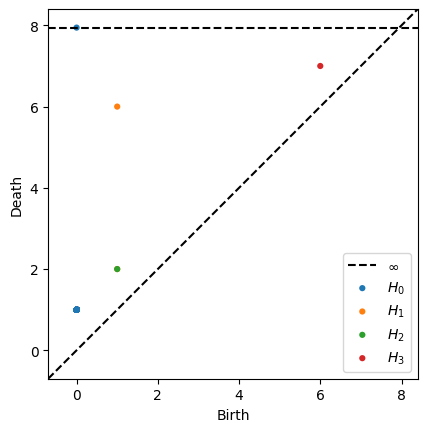

In [10]:
plot_diagrams(diagrams, show=True) # SCATTER PLOT